In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Đường dẫn chính xác tuyệt đối chứa tên file thực tế trên Colab của bạn
path = '/content/processed_dulieuxettuyendaihoc (1).csv'

df = pd.read_csv(path)
print("🎉 Đã nạp dữ liệu thành công!")
df.head()

🎉 Đã nạp dữ liệu thành công!


,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,...,TBM1,TBM2,TBM3,XL1,XL2,XL3,US_TBM1,US_TBM2,US_TBM3,KQXT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,...,7.00,7.54,7.01,K,K,K,2.930693,3.029126,2.537143,0
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,...,4.69,5.47,5.07,Y,TB,TB,0.643564,1.019417,0.320000,0
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,...,5.77,5.38,6.04,TB,TB,TB,1.712871,0.932039,1.428571,1
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,...,6.21,5.20,6.88,TB,TB,K,2.148515,0.757282,2.388571,0
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,...,6.50,6.36,6.99,K,TB,K,2.435644,1.883495,2.514286,0


=== PHẦN 2: TRÌNH BÀY DỮ LIỆU (ĐÃ SỬA LỖI) ===

Bảng tần số & tần suất biến GT:
     Tần số  Tần suất (%)
GT                      
M       52          52.0
F       48          48.0


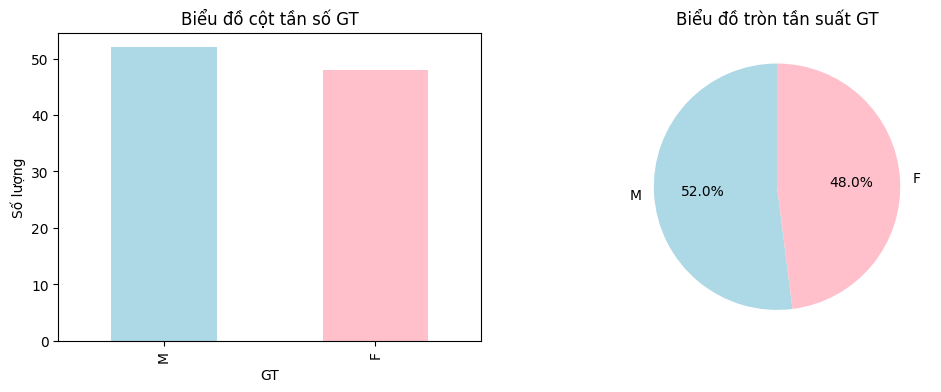

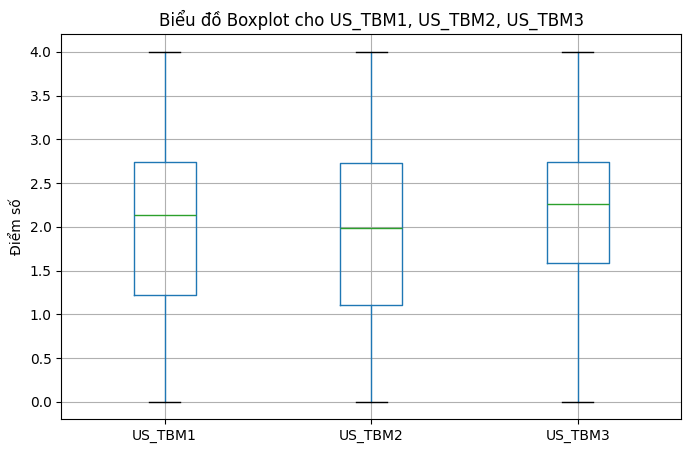

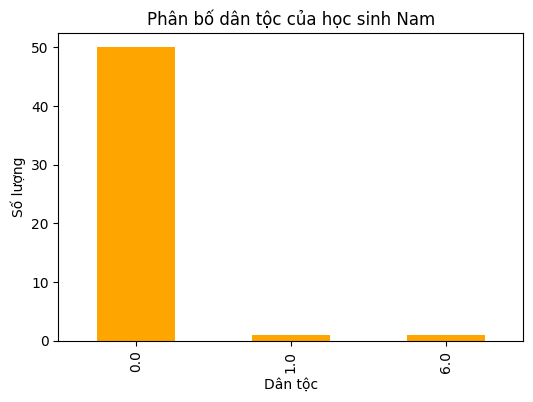


⚠️ Không có học sinh Nam người Kinh nào thỏa mãn điều kiện điểm số ở Câu 4 (Không thể vẽ biểu đồ cột).


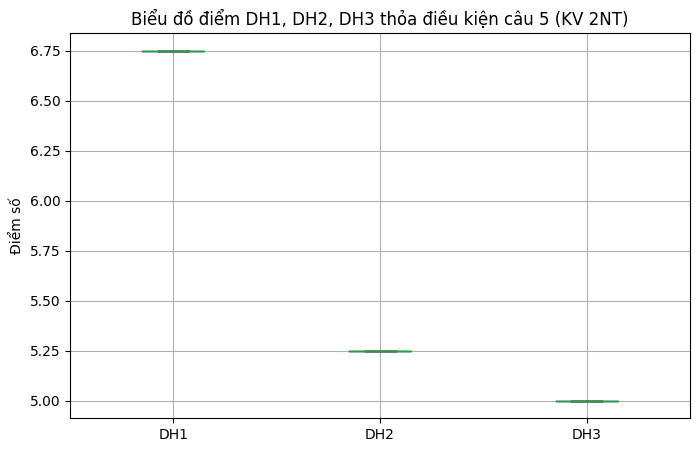

In [16]:
print("=== PHẦN 2: TRÌNH BÀY DỮ LIỆU (ĐÃ SỬA LỖI) ===\n")

# 1. Trình bày dữ liệu biến: GT
tanso_gt = df['GT'].value_counts()
tansuat_gt = df['GT'].value_counts(normalize=True) * 100
print("Bảng tần số & tần suất biến GT:\n", pd.DataFrame({'Tần số': tanso_gt, 'Tần suất (%)': tansuat_gt}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tanso_gt.plot(kind='bar', ax=axes[0], color=['lightblue', 'pink'])
axes[0].set_title('Biểu đồ cột tần số GT')
axes[0].set_ylabel('Số lượng')

tanso_gt.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['lightblue', 'pink'], startangle=90)
axes[1].set_title('Biểu đồ tròn tần suất GT')
axes[1].set_ylabel('')
plt.show()

# 2. Trình bày dữ liệu biến: US_TBM1, US_TBM2 và US_TBM3 bằng Boxplot
plt.figure(figsize=(8, 5))
df[['US_TBM1', 'US_TBM2', 'US_TBM3']].boxplot()
plt.title('Biểu đồ Boxplot cho US_TBM1, US_TBM2, US_TBM3')
plt.ylabel('Điểm số')
plt.show()

# 3. Trình bày dữ liệu biến DT với các học sinh là nam
df_nam = df[df['GT'] == 'M']
plt.figure(figsize=(6, 4))
df_nam['DT'].value_counts().plot(kind='bar', color='orange')
plt.title('Phân bố dân tộc của học sinh Nam')
plt.xlabel('Dân tộc')
plt.ylabel('Số lượng')
plt.show()

# 4. Trình bày dữ liệu biến KV với các học sinh là nam thuộc dân tộc Kinh và đạt chuẩn điểm số
cond_c4 = (df['GT'] == 'M') & (df['DT'] == 'Kinh') & (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)
df_filtered_c4 = df[cond_c4]

# Kiểm tra nếu có dữ liệu thì mới vẽ biểu đồ để tránh lỗi IndexError
if not df_filtered_c4.empty:
    plt.figure(figsize=(6, 4))
    df_filtered_c4['KV'].value_counts().plot(kind='bar', color='purple')
    plt.title('Phân bố KV học sinh Nam - Kinh đạt chuẩn')
    plt.xlabel('Khu vực')
    plt.ylabel('Số lượng')
    plt.show()
else:
    print("\n⚠️ Không có học sinh Nam người Kinh nào thỏa mãn điều kiện điểm số ở Câu 4 (Không thể vẽ biểu đồ cột).")

# 5. Trình bày dữ liệu lần lượt các biến DH1, DH2, DH3 lớn hơn bằng 5.0 và thuộc khu vực 2NT
cond_c5 = (df['DH1'] >= 5.0) & (df['DH2'] >= 5.0) & (df['DH3'] >= 5.0) & (df['KV'] == '2NT')
df_filtered_c5 = df[cond_c5]

# Kiểm tra nếu có dữ liệu mới vẽ Boxplot
if not df_filtered_c5.empty:
    plt.figure(figsize=(8, 5))
    df_filtered_c5[['DH1', 'DH2', 'DH3']].boxplot()
    plt.title('Biểu đồ điểm DH1, DH2, DH3 thỏa điều kiện câu 5 (KV 2NT)')
    plt.ylabel('Điểm số')
    plt.show()
else:
    print("⚠️ Không có học sinh nào thuộc khu vực 2NT có cả 3 điểm DH1, DH2, DH3 đều >= 5.0 (Không thể vẽ Boxplot).")

=== PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU THEO NHÓM PHÂN LOẠI ===



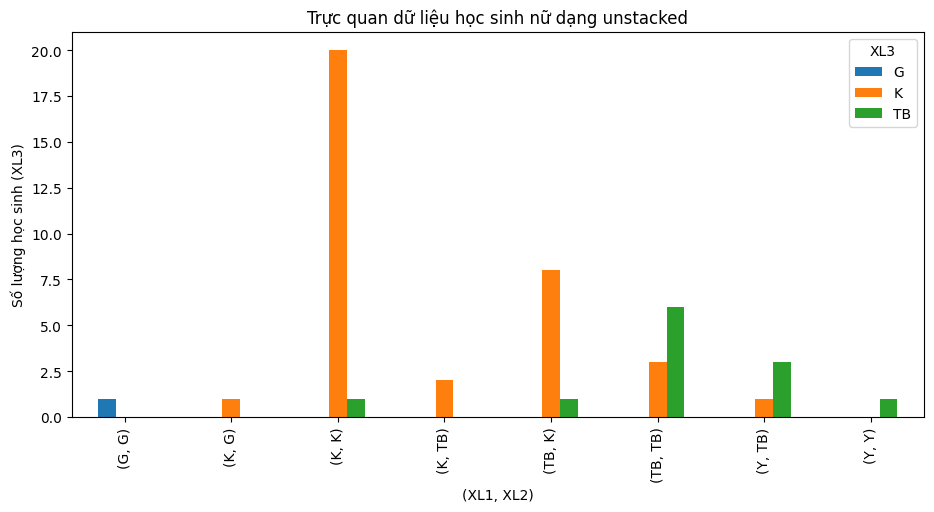

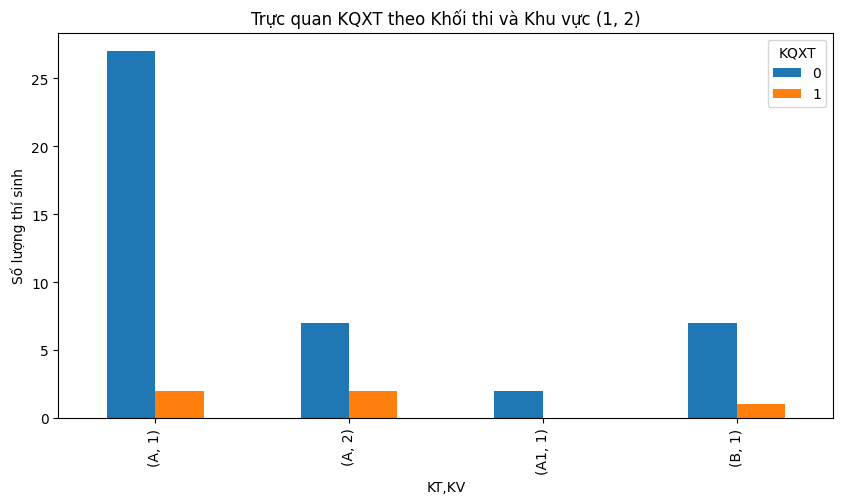

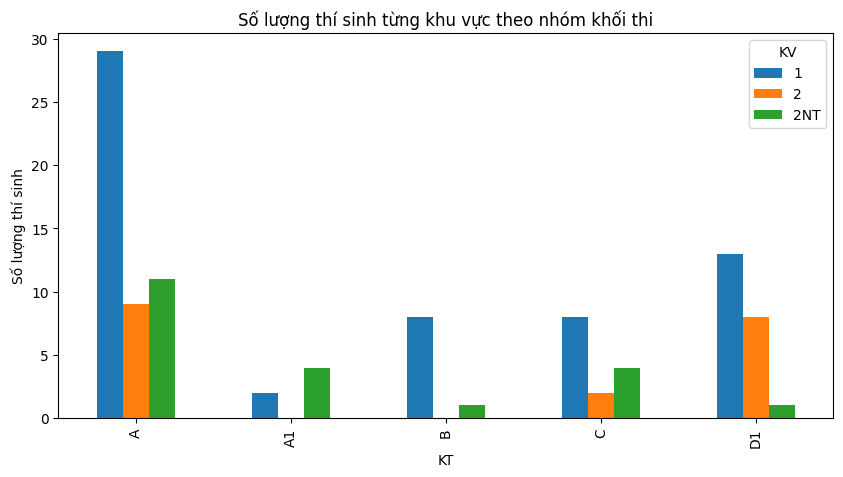

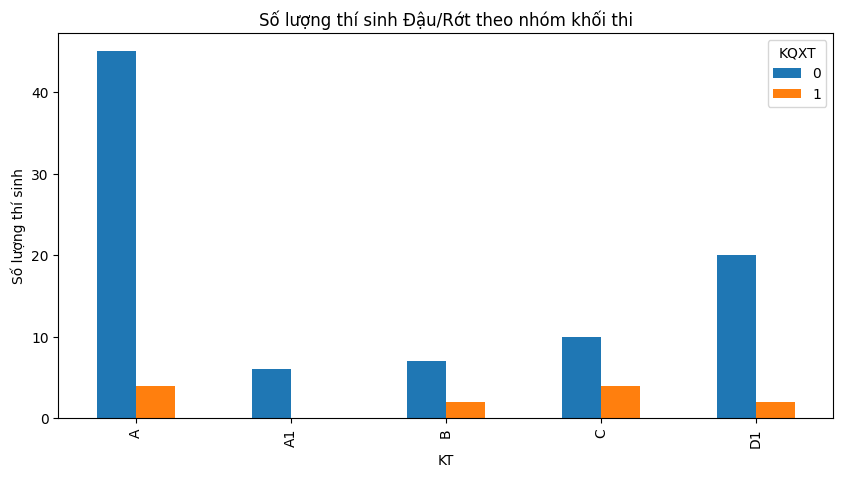

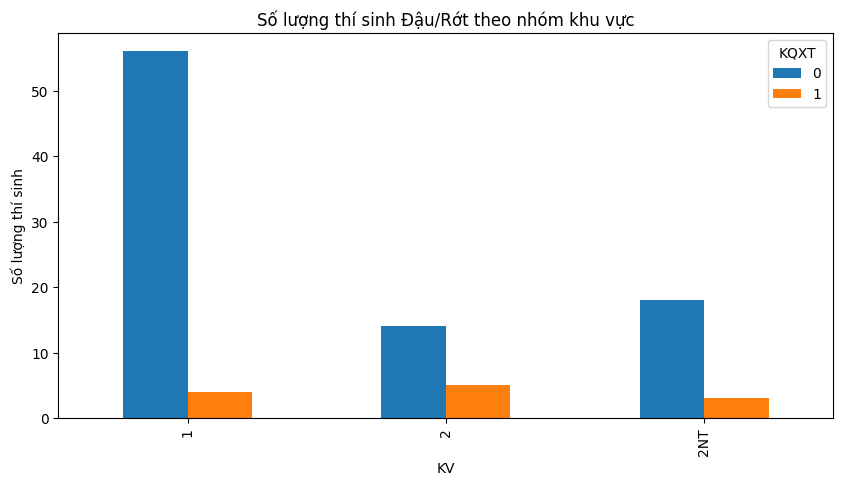

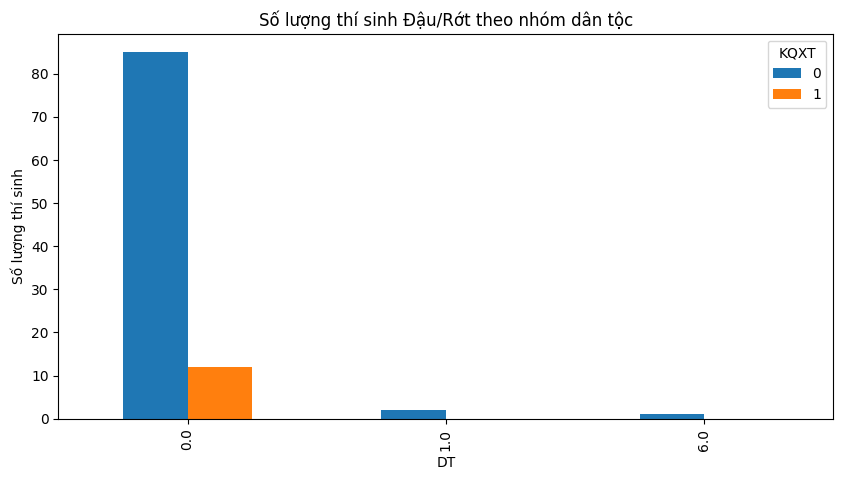

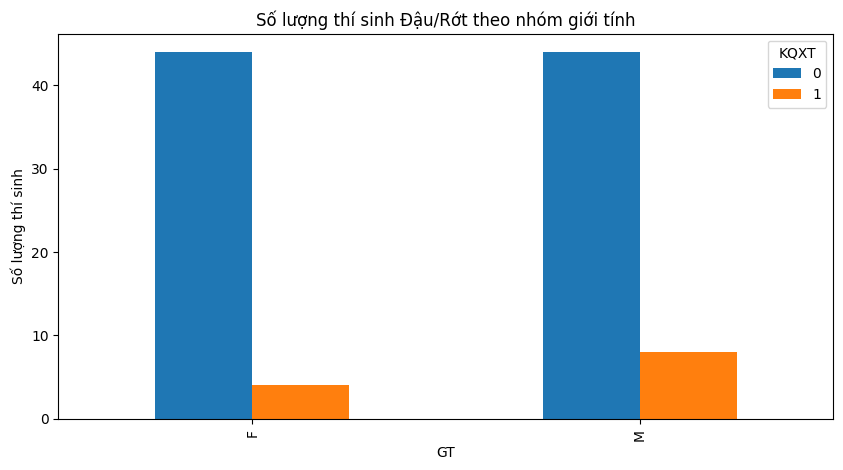

In [17]:
print("=== PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU THEO NHÓM PHÂN LOẠI ===\n")

# 1. Trực quan học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
df_nu = df[df['GT'] == 'F']
if not df_nu.empty and 'XL1' in df.columns and 'XL2' in df.columns and 'XL3' in df.columns:
    df_nu_group = df_nu.groupby(['XL1', 'XL2'])['XL3'].value_counts().unstack(fill_value=0)
    if not df_nu_group.empty:
        df_nu_group.plot(kind='bar', stacked=False, figsize=(11, 5))
        plt.title('Trực quan dữ liệu học sinh nữ dạng unstacked')
        plt.xlabel('(XL1, XL2)')
        plt.ylabel('Số lượng học sinh (XL3)')
        plt.legend(title='XL3')
        plt.show()
else:
    print("⚠️ Không có dữ liệu nữ hoặc thiếu các cột xếp loại XL1, XL2, XL3.")

# 2. Trực quan dữ liệu KQXT trên nhóm học sinh có khối thi A, A1, B thuộc khu vực 1, 2
if 'KQXT' in df.columns:
    df_c2 = df[df['KT'].isin(['A', 'A1', 'B']) & df['KV'].isin(['1', '2'])]
    if not df_c2.empty:
        df_c2.groupby(['KT', 'KV'])['KQXT'].value_counts().unstack(fill_value=0).plot(kind='bar', stacked=False, figsize=(10, 5))
        plt.title('Trực quan KQXT theo Khối thi và Khu vực (1, 2)')
        plt.ylabel('Số lượng thí sinh')
        plt.show()
else:
    print("⚠️ File dữ liệu của bạn chưa có cột 'KQXT' (Kết quả xét tuyển).")

# 3. Trực quan dữ liệu số lượng thí sinh từng khu vực dựa trên từng nhóm khối thi
df.groupby('KT')['KV'].value_counts().unstack(fill_value=0).plot(kind='bar', stacked=False, figsize=(10, 5))
plt.title('Số lượng thí sinh từng khu vực theo nhóm khối thi')
plt.ylabel('Số lượng thí sinh')
plt.show()

# 4. Trực quan dữ liệu số lượng thí sinh đậu, rớt trên từng nhóm khối thi
if 'KQXT' in df.columns:
    df.groupby('KT')['KQXT'].value_counts().unstack(fill_value=0).plot(kind='bar', stacked=False, figsize=(10, 5))
    plt.title('Số lượng thí sinh Đậu/Rớt theo nhóm khối thi')
    plt.ylabel('Số lượng thí sinh')
    plt.show()

# 5. Trực quan dữ liệu số lượng thí sinh đậu rớt trên từng nhóm khu vực
if 'KQXT' in df.columns:
    df.groupby('KV')['KQXT'].value_counts().unstack(fill_value=0).plot(kind='bar', stacked=False, figsize=(10, 5))
    plt.title('Số lượng thí sinh Đậu/Rớt theo nhóm khu vực')
    plt.ylabel('Số lượng thí sinh')
    plt.show()

# 6. Trực quan dữ liệu số lượng thí sinh đậu rớt dựa trên từng nhóm dân tộc
if 'KQXT' in df.columns:
    df.groupby('DT')['KQXT'].value_counts().unstack(fill_value=0).plot(kind='bar', stacked=False, figsize=(10, 5))
    plt.title('Số lượng thí sinh Đậu/Rớt theo nhóm dân tộc')
    plt.ylabel('Số lượng thí sinh')
    plt.show()

# 7. Trực quan dữ liệu số lượng thí sinh đậu rớt dựa trên từng nhóm giới tính
if 'KQXT' in df.columns:
    df.groupby('GT')['KQXT'].value_counts().unstack(fill_value=0).plot(kind='bar', stacked=False, figsize=(10, 5))
    plt.title('Số lượng thí sinh Đậu/Rớt theo nhóm giới tính')
    plt.ylabel('Số lượng thí sinh')
    plt.show()

=== PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO ===



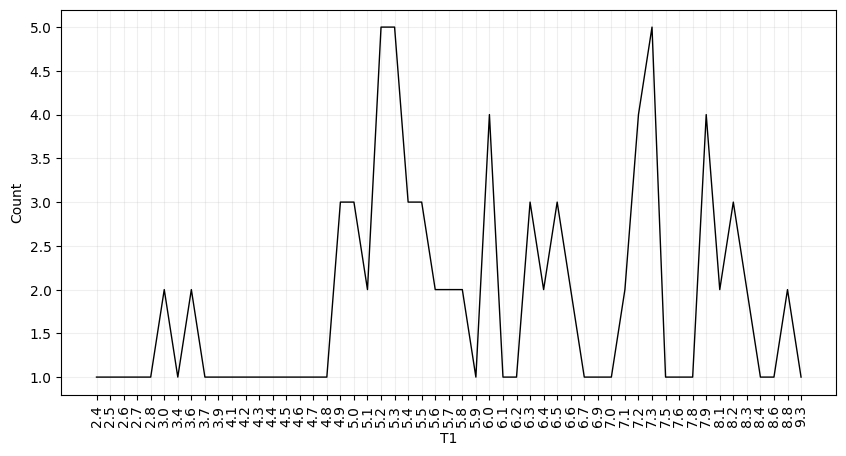

Bảng tần số cho biến phanlopt1:
 phanlopt1
tb    46
k     23
kh    19
g     12
Name: count, dtype: int64


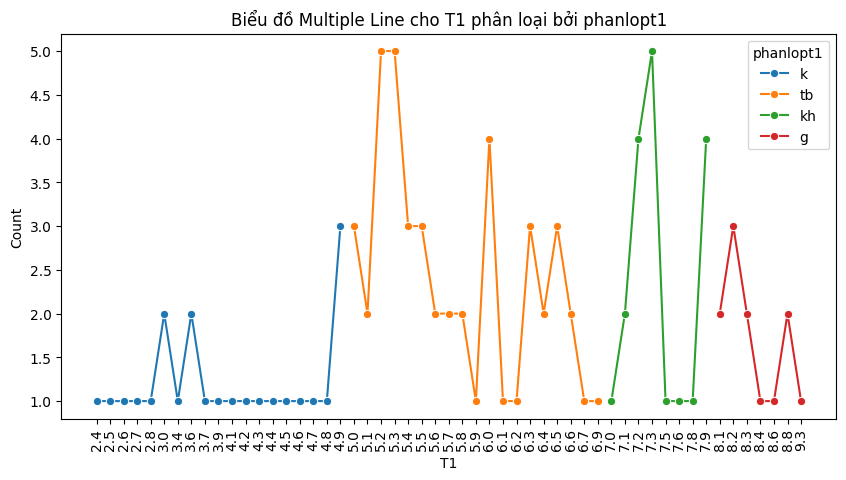

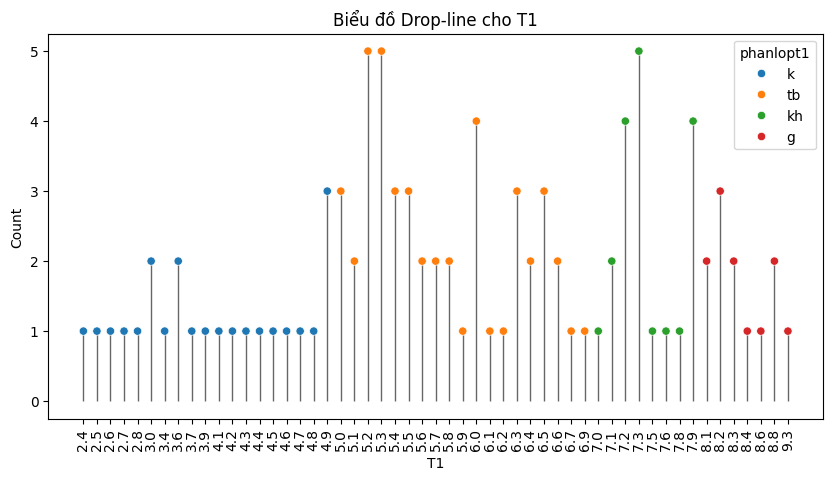

In [18]:
print("=== PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO ===\n")

# 1. Vẽ biểu đồ đường Simple cho biến T1 (Khớp chính xác hình dạng mẫu số 1)
t1_counts = df['T1'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.plot(t1_counts.index.astype(str), t1_counts.values, color='black', linewidth=1)
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.xlabel('T1')
plt.grid(True, alpha=0.2)
plt.show()

# 2. Tạo biến phân loại (phanlopt1) cho môn toán (T1) theo quy tắc
def chia_nhom_t1(diem):
    if diem < 5: return 'k'
    elif 5 <= diem < 7: return 'tb'
    elif 7 <= diem < 8: return 'kh'
    else: return 'g'

df['phanlopt1'] = df['T1'].apply(chia_nhom_t1)

# 3. Lập bảng tần số cho biến phanlopt1
print("Bảng tần số cho biến phanlopt1:\n", df['phanlopt1'].value_counts())

# 4. Vẽ biểu đồ đường Multiple Line cho biến T1 được phân loại bởi phanlopt1 (Hình mẫu số 2)
plt.figure(figsize=(10, 5))
df_sorted_t1 = df.sort_values(by='T1')
df_counts_group = df_sorted_t1.groupby(['T1', 'phanlopt1']).size().reset_index(name='Count')
sns.lineplot(data=df_counts_group, x=df_counts_group['T1'].astype(str), y='Count', hue='phanlopt1', marker='o')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.xlabel('T1')
plt.title('Biểu đồ Multiple Line cho T1 phân loại bởi phanlopt1')
plt.show()

# 5. Vẽ biểu đồ Drop-line cho biến T1 được phân loại bởi phanlopt1 (Hình mẫu số 3)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_counts_group, x=df_counts_group['T1'].astype(str), y='Count', hue='phanlopt1', zorder=3)
# Vẽ các đường dọc thả từ điểm dữ liệu xuống trục hoành (Drop-line)
for idx, row in df_counts_group.iterrows():
    plt.vlines(x=str(row['T1']), ymin=0, ymax=row['Count'], colors='black', linewidth=1, alpha=0.6)
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.xlabel('T1')
plt.title('Biểu đồ Drop-line cho T1')
plt.show()

=== PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI ===

Mô tả thống kê tập trung & phân tán của T1:
 count    100.000000
mean       5.946000
std        1.608338
min        2.400000
25%        5.000000
50%        5.850000
75%        7.200000
max        9.300000
Name: T1, dtype: float64


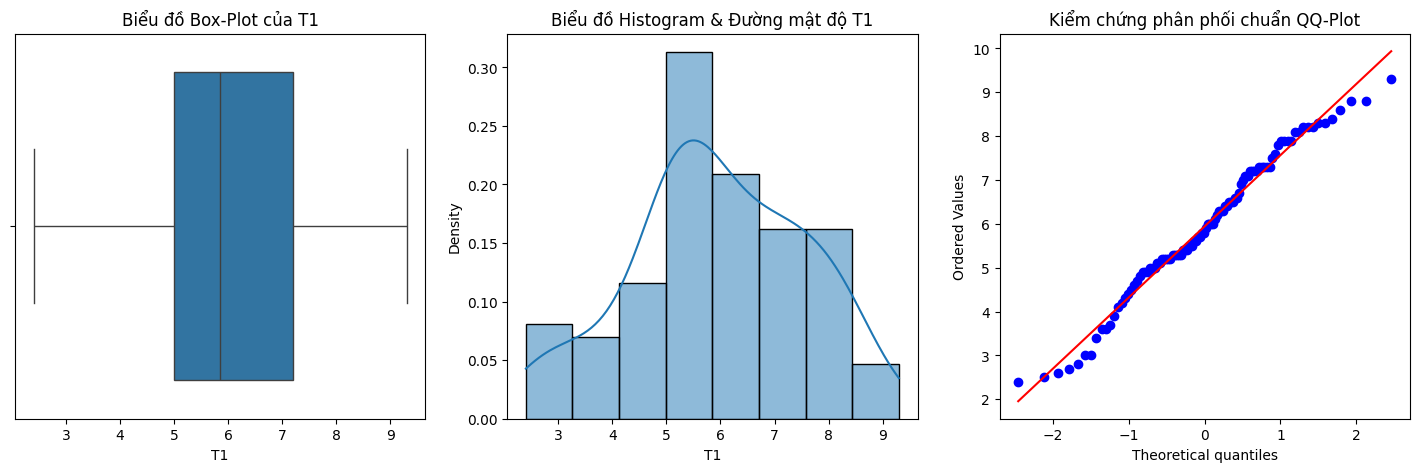

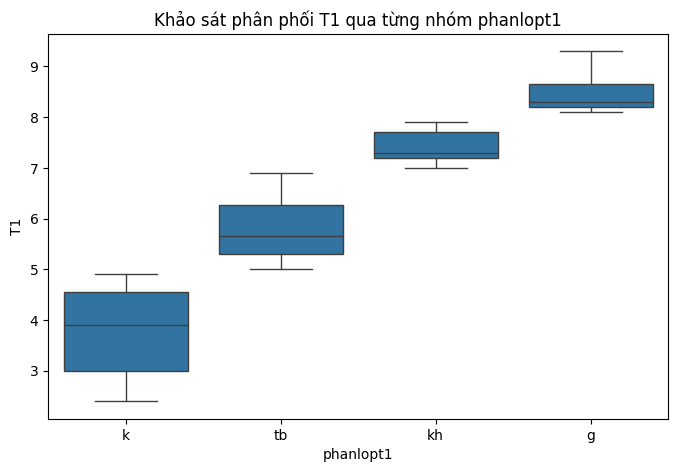

Hiệp phương sai (Covariance) giữa T1 và DH1: 0.11283838383838381
Hệ số tương quan (Correlation) giữa T1 và DH1: 0.04925439216104145


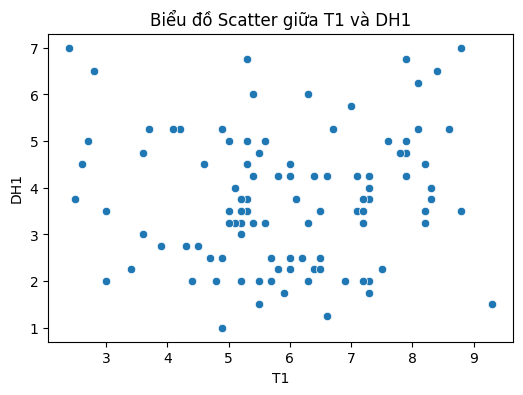

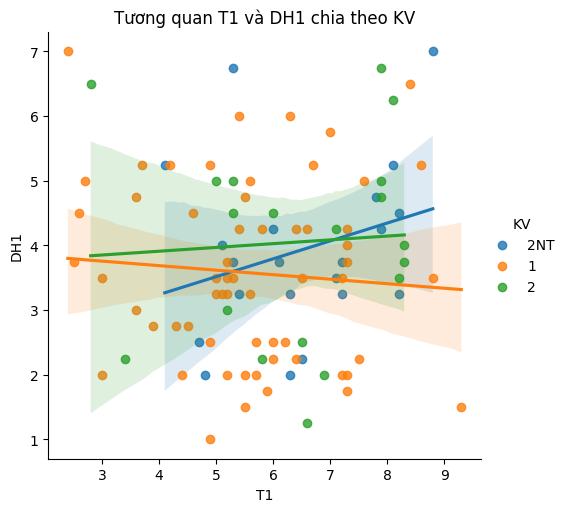

Ma trận tương quan giữa DH1, DH2, DH3:
           DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000


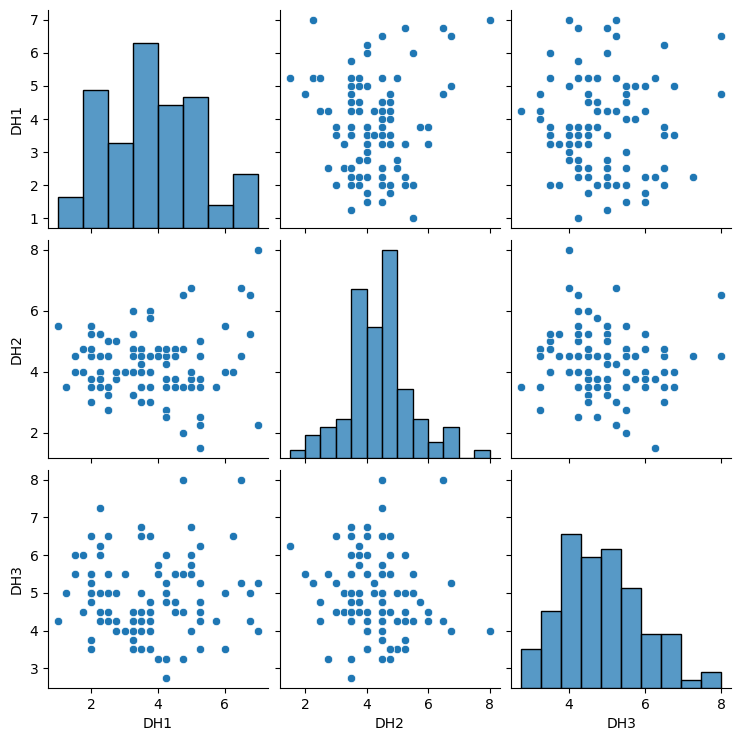

In [19]:
print("=== PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI ===\n")

# 1. Hãy mô tả và khảo sát phân phối cho biến T1
print("Mô tả thống kê tập trung & phân tán của T1:\n", df['T1'].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Biểu đồ Box-Plot để xác định các đại lượng tập trung và phân tán
sns.boxplot(x=df['T1'], ax=axes[0])
axes[0].set_title('Biểu đồ Box-Plot của T1')

# Biểu đồ Histogram & Đường mật độ để khảo sát hình dáng lệch
sns.histplot(df['T1'], kde=True, ax=axes[1], stat="density")
axes[1].set_title('Biểu đồ Histogram & Đường mật độ T1')

# Kiểm chứng phân phối chuẩn bằng QQ-Plot
stats.probplot(df['T1'], dist="norm", plot=axes[2])
axes[2].set_title('Kiểm chứng phân phối chuẩn QQ-Plot')
plt.show()

# 2. Hãy mô tả và khảo sát phân phối cho biến T1 trên từng nhóm phân lớp (phanlopt1)
plt.figure(figsize=(8, 5))
sns.boxplot(x='phanlopt1', y='T1', data=df, order=['k', 'tb', 'kh', 'g'])
plt.title('Khảo sát phân phối T1 qua từng nhóm phanlopt1')
plt.show()

# 3. Hãy khảo sát tương quan giữa biến DH1 theo biến T1
covariance_t1_dh1 = df['DH1'].cov(df['T1'])
correlation_t1_dh1 = df['DH1'].corr(df['T1'])
print(f"Hiệp phương sai (Covariance) giữa T1 và DH1: {covariance_t1_dh1}")
print(f"Hệ số tương quan (Correlation) giữa T1 và DH1: {correlation_t1_dh1}")

plt.figure(figsize=(6, 4))
sns.scatterplot(x='T1', y='DH1', data=df)
plt.title('Biểu đồ Scatter giữa T1 và DH1')
plt.show()

# 4. Hãy khảo sát tương quan giữa biến DH1 theo biến T1 trên từng nhóm khu vực
sns.lmplot(x='T1', y='DH1', hue='KV', data=df, height=5)
plt.title('Tương quan T1 và DH1 chia theo KV')
plt.show()

# 5. Hãy khảo sát tương quan giữa các biến DH1, DH2, DH3
print("Ma trận tương quan giữa DH1, DH2, DH3:\n", df[['DH1', 'DH2', 'DH3']].corr())
sns.pairplot(df[['DH1', 'DH2', 'DH3']])
plt.show()